In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
np.random.seed(9191)

# Loading Data

In [3]:
#loading data
data_dir = Path("/mnt/a/uni/data visualization project/Amazon Sales Dataset/amazon.csv")
if not data_dir.exists():
    print(f"Error: The file was NOT found at the specified path: {data_dir}")
    print("Please check the path and file name.")
else:
    # Step 2: If the file exists, load it
    print(f"Success: The CSV file was found at {data_dir.name}.")
df = pd.read_csv(data_dir)

df.head()



Success: The CSV file was found at amazon.csv.


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
combined_df = df.copy()

In [5]:
combined_df.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

# overall check

In [6]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [7]:
#total number of duplicate rows
combined_df.duplicated().sum()

np.int64(0)

In [8]:
#Null value percentage
(combined_df.isnull().sum() / len(combined_df)) * 100

product_id             0.000000
product_name           0.000000
category               0.000000
discounted_price       0.000000
actual_price           0.000000
discount_percentage    0.000000
rating                 0.000000
rating_count           0.136519
about_product          0.000000
user_id                0.000000
user_name              0.000000
review_id              0.000000
review_title           0.000000
review_content         0.000000
img_link               0.000000
product_link           0.000000
dtype: float64

# fix data types

In [9]:
#fixing actual_price
combined_df['actual_price'] = combined_df['actual_price'].astype(str)
# Remove the currency symbol ('₹') and the thousands separator (',')
combined_df['actual_price'] = combined_df['actual_price'].str.replace('₹', '', regex=False)
combined_df['actual_price'] = combined_df['actual_price'].str.replace(',', '', regex=False)
#Convert the cleaned string column to the target numeric type (float64)
combined_df['actual_price'] = combined_df['actual_price'].astype('float64')

#fixing discounted_price
combined_df['discounted_price'] = combined_df['discounted_price'].astype(str)
# Remove the currency symbol ('₹') and the thousands separator (',')
combined_df['discounted_price'] = combined_df['discounted_price'].str.replace('₹', '', regex=False)
combined_df['discounted_price'] = combined_df['discounted_price'].str.replace(',', '', regex=False)
#Convert the cleaned string column to the target numeric type (float64)
combined_df['discounted_price'] = combined_df['discounted_price'].astype('float64')

#fixing discount_percentage
combined_df['discount_percentage'] = combined_df['discount_percentage'].astype(str)
# Remove the currency symbol ('%')
combined_df['discount_percentage'] = combined_df['discount_percentage'].str.replace('%', '', regex=False)
#Convert the cleaned string column to the target numeric type (float64)
combined_df['discount_percentage'] = combined_df['discount_percentage'].astype('float64')



In [10]:
#found one row with "|" in the "rating" column
# Create a temporary string version of the 'rating' column to enable string operations.
combined_df['rating_str'] = combined_df['rating'].astype(str)

#Filter rows containing the pipe character ('|').
rows_with_pipe = combined_df[combined_df['rating_str'].str.contains('\\|', regex=True, na=False)]

# Report the findings and display the rows.
if rows_with_pipe.empty:
    print("No rows found with '|' in the 'rating' column.")
else:
    print(f"Rows found with '|' in 'rating': {len(rows_with_pipe)}")
    # Display key columns for inspection using to_string to avoid external libraries like tabulate
    print(rows_with_pipe[['product_name', 'rating', 'category']].to_string(index=False))

    # Delete the row(s) with the pipe character.
    combined_df.drop(rows_with_pipe.index, inplace=True)
    print(f"\nSuccessfully deleted {len(rows_with_pipe)} rows from combined_df.")
    
# Clean up the temporary column
combined_df.drop(columns=['rating_str'], inplace=True, errors='ignore')

Rows found with '|' in 'rating': 1
                                                                                                                                               product_name rating                                                                                              category
Eureka Forbes car Vac 100 Watts Powerful Suction Vacuum Cleaner with Washable HEPA Filter, 3 Accessories,Compact,Light Weight & Easy to use (Black and Red)      | Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|HandheldVacuums

Successfully deleted 1 rows from combined_df.


In [ ]:
#fixing rating
#Convert the cleaned string column to the target numeric type (float64)
combined_df['rating'] = combined_df['rating'].astype('float64')

#fixing rating_count
# Remove commas (,) from all string entries in the 'rating_count' column.
# The .str accessor automatically ignores existing NaN values, keeping them intact.
combined_df['rating_count'] = combined_df['rating_count'].str.replace(',', '', regex=False)
# Convert the cleaned strings to a numeric type.
combined_df['rating_count'] = pd.to_numeric(combined_df['rating_count'], errors='coerce')

In [12]:
# rating count column has 2 Nan values and delete the NAN vlaue rows
rows_before = len(combined_df)
combined_df.dropna(subset=['rating_count'], inplace=True)

In [13]:
combined_df.dtypes

product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object

In [14]:
#Profit Margin
combined_df["profit_percentage"] = ((combined_df["actual_price"] - combined_df["discounted_price"]) / combined_df["actual_price"]) * 100

In [15]:
#Categorize discounts to show which products have high discounts
# Define the conditions
conditions = [
    combined_df['discount_percentage'] > 60,
    combined_df['discount_percentage'] > 30 
]

# Define the values to assign when conditions are True
choices = [
    "High",
    "Medium"
]

# Apply the conditions to create the new 'discount_level' column.
# 'default="Low"' handles the 'else' case (where discount is 30% or less).
combined_df['discount_level'] = np.select(conditions, choices, default="Low")


In [16]:
#Split products into “Low, Mid, High” price groups using quartiles
combined_df["price_category"] = pd.qcut(combined_df["discounted_price"], q=3, labels=["Low", "Mid", "High"])
# Count the occurrences of each category (High, Low, Mid) in the 'price_category' column
combined_df['price_category'].value_counts()


price_category
Low     497
Mid     496
High    469
Name: count, dtype: int64

In [17]:
combined_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,profit_percentage,discount_level,price_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,63.694268,High,Low
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,42.979943,Medium,Low
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,89.520800,High,Low
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,52.932761,Medium,Low
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,61.403509,High,Low


### Find correlation between pricing, discount, and ratings

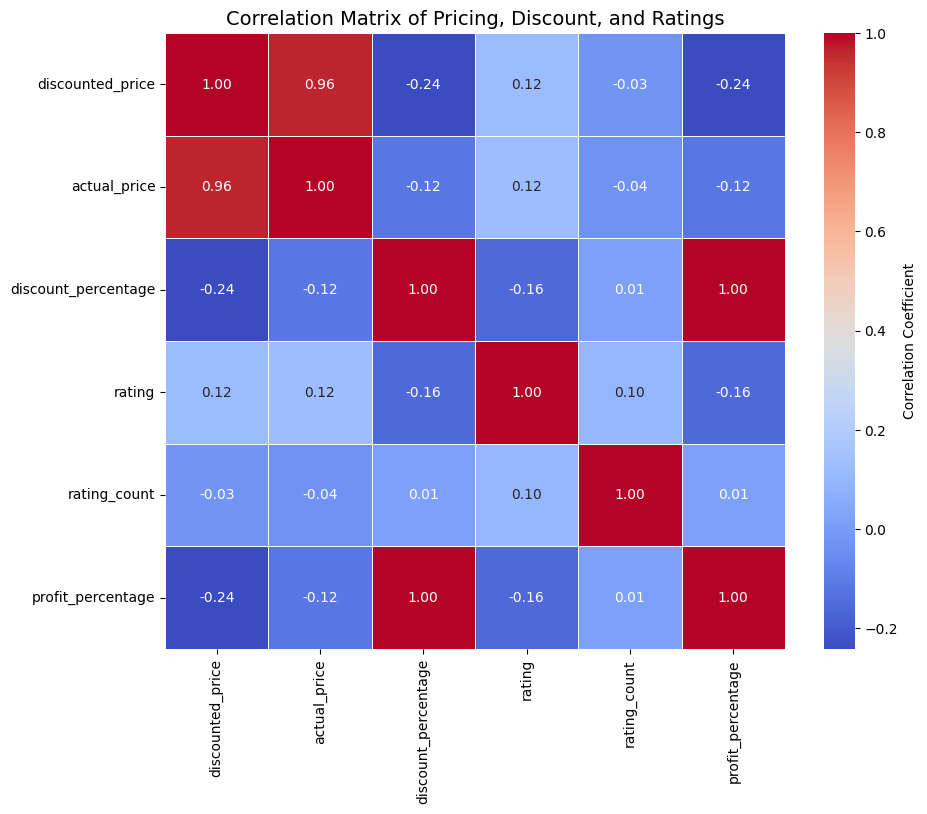

In [ ]:
# Calculate the correlation matrix for all numeric columns in combined_df
correlation_matrix = combined_df.corr(numeric_only=True)

# Visualization: Display as a Heatmap
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, 
            annot=True,        
            cmap="coolwarm",   
            fmt=".2f",         
            linewidths=.5,    
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix of Pricing, Discount, and Ratings', fontsize=14)
plt.show()


### Predict product rating or discounted price using a few numeric columns.

In [ ]:
# Define Features (X) and Target (y)
X = combined_df[["actual_price", "discount_percentage"]]

# Target variable
y = combined_df["discounted_price"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate Model
print("--- Simple Linear Regression Results ---")
print(f"Features used: actual_price, discount_percentage")
print(f"Target variable: discounted_price")
print("-" * 37)
print(f"R² Score (Model Performance): {model.score(X_test, y_test):.4f}")
print("-" * 37)


--- Simple Linear Regression Results ---
Features used: actual_price, discount_percentage
Target variable: discounted_price
-------------------------------------
R² Score (Model Performance): 0.9500
-------------------------------------


##### The R² score of 0.9500 means the model explains 95% of the variability in the discounted price, confirming a strong, expected linear relationship between the original price, the discount percentage, and the final price.

In [20]:
# extract finished EXCEL file
output_file_path = "/mnt/a/uni/data visualization project/Amazon Sales Dataset/amazon_sales_analysis.xlsx"
combined_df.to_excel(output_file_path, index=False)

print(f"Success! The cleaned data has been exported to: {output_file_path}")


Success! The cleaned data has been exported to: /mnt/a/uni/data visualization project/Amazon Sales Dataset/amazon_sales_analysis.xlsx
